# Parte 1 — Importação e Preparação dos Dados

In [ ]:
#Para saber destino das instalações das bibliotecas
import sys
print(sys.executable)

C:\Users\yeong\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe


In [26]:
#Definindo pastas para salvas tabelas e gráficos
import os

# Definindo os caminhos relativos para salvar os resultados
PASTA_GRAFICOS = '../outputs/graphs/'
PASTA_TABELAS = '../outputs/tables/'

# Garantindo que as pastas existem
os.makedirs(PASTA_GRAFICOS, exist_ok=True)
os.makedirs(PASTA_TABELAS, exist_ok=True)

In [ ]:
# Instalando bibliotecas
import sys
!{sys.executable} -m pip install pandas openpyxl matplotlib seaborn numpy scipy

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\yeong\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached matplotlib-3.11.0-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached matplotlib-3.11.0-cp312-cp312-win_amd64.whl (9.3 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\yeong\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Carregando arquivo
df = pd.read_excel('..\data\Plano De Saúde Database.xlsx', sheet_name='Dados')

# Checando primeiras linhas
df.head()

<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
C:\Users\yeong\AppData\Local\Temp\ipykernel_9068\3218168652.py:8: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_excel('..\data\Plano De Saúde Database.xlsx', sheet_name='Dados')


,Idade,IMC,Qte_Filhos,Fumante,Região,Custo_Saude,Sexo
0,19,27.900,0,Sim,Centro,1688.492400,Feminino
1,18,33.770,1,Não,Sudeste,172.555230,Masculino
2,28,33.000,3,Não,Sudeste,444.946200,Masculino
3,33,22.705,0,Não,Norte,2198.447061,Masculino
4,32,28.880,0,Não,Norte,386.685520,Masculino


In [16]:
# Criando coluna Fumante_Boolean para melhor utilização nos dados na análise
df['Fumante_Boolean'] = df['Fumante'].map({'Sim': 1, 'Não': 0})

#Checando
df.head()

,Idade,IMC,Qte_Filhos,Fumante,Região,Custo_Saude,Sexo,Fumante_Boolean
0,19,27.900,0,Sim,Centro,1688.492400,Feminino,1
1,18,33.770,1,Não,Sudeste,172.555230,Masculino,0
2,28,33.000,3,Não,Sudeste,444.946200,Masculino,0
3,33,22.705,0,Não,Norte,2198.447061,Masculino,0
4,32,28.880,0,Não,Norte,386.685520,Masculino,0


In [23]:
#Criando coluna IMC Faixas para melhor utilização dos dados na análise
def classificar_imc(imc):
    if imc < 17:
        return 'Muito abaixo do peso'
    elif imc <= 18.49:
        return 'Abaixo do peso'
    elif imc <= 24.99:
        return 'Peso normal'
    elif imc <= 29.99:
        return 'Acima do peso'
    elif imc <= 34.99:
        return 'Obesidade I'
    elif imc <= 39.99:
        return 'Obesidade II (Severa)'
    else:
        return 'Obesidade III (Mórbida)'

df['IMC Faixas'] = df['IMC'].apply(classificar_imc)

#Checando
df.head()


,Idade,IMC,Qte_Filhos,Fumante,Região,Custo_Saude,Sexo,Fumante_Boolean,IMC Faixas
0,19,27.900,0,Sim,Centro,1688.492400,Feminino,1,Acima do peso
1,18,33.770,1,Não,Sudeste,172.555230,Masculino,0,Obesidade I
2,28,33.000,3,Não,Sudeste,444.946200,Masculino,0,Obesidade I
3,33,22.705,0,Não,Norte,2198.447061,Masculino,0,Peso normal
4,32,28.880,0,Não,Norte,386.685520,Masculino,0,Acima do peso


Para melhor aproveitar as informações disponibilizadas, era necessário criar duas novas colunas:
- Fumante_Boolean, para que fosse possível contabilizar o número de fumantes e realizar as operações adequadas
- IMC Faixas, para dividir em grupos os funcionários, e assim obter gráficos mais legíveis

A tabela de faixas de IMC utilizada foi a adotada pela OMS, disponível em https://calculacentro.com/calculadora/imc

# Parte 2 — Análise Exploratória

### Tabelas de Frequência (variáveis categóricas)
#### Tabela de frequência para Sexo

In [56]:
# Criando tabela de frequência para a variável Sexo
freq_sexo = df['Sexo'].value_counts().reset_index()
freq_sexo.columns = ['Sexo', 'Freq Absoluta']
# Ordenando resultados do menor pro maior
freq_sexo = freq_sexo.sort_values(by='Freq Absoluta', ascending=True)
freq_sexo['Freq Relativa'] = freq_sexo['Freq Absoluta'] / len(df) *100
freq_sexo['Freq Acumulada'] = freq_sexo['Freq Relativa'].cumsum()

# Salvando resultados na pasta de tabelas
freq_sexo.to_csv(f'{PASTA_TABELAS}resumo_por_sexo.csv', sep=';', encoding='utf-8-sig')

# Adicionando fundo gradiente para melhor visualização
freq_sexo.style.background_gradient(subset='Freq Acumulada', cmap="BuPu")

,Sexo,Freq Absoluta,Freq Relativa,Freq Acumulada
1,Feminino,662,49.476831,49.476831
0,Masculino,676,50.523169,100.000000


#### Tabela de frequência para Fumante

In [57]:
#Criando tabela de frequência para a variável Fumante
freq_fumante = df['Fumante'].value_counts().reset_index()
freq_fumante.columns = ['Fumante', 'Freq Absoluta']
# Ordenando resultados do menor pro maior
freq_fumante = freq_fumante.sort_values(by='Freq Absoluta', ascending=True)
freq_fumante['Freq Relativa'] = freq_fumante['Freq Absoluta'] / len(df) *100
freq_fumante['Freq Acumulada'] = freq_fumante['Freq Relativa'].cumsum()

# Salvando resultados na pasta de tabelas
freq_fumante.to_csv(f'{PASTA_TABELAS}resumo_por_fumante.csv', sep=';', encoding='utf-8-sig')


# Adicionando fundo gradiente para melhor visualização
freq_fumante.style.background_gradient(subset='Freq Acumulada', cmap="BuPu")

,Fumante,Freq Absoluta,Freq Relativa,Freq Acumulada
1,Sim,274,20.478326,20.478326
0,Não,1064,79.521674,100.000000


#### Tabela de frequência para Região

In [58]:
#Criando tabela de frequência para a variável Região
freq_regiao = df['Região'].value_counts().reset_index()
freq_regiao.columns = ['Região', 'Freq Absoluta']
# Ordenando resultados do menor pro maior
freq_regiao = freq_regiao.sort_values(by='Freq Absoluta', ascending=True)
freq_regiao['Freq Relativa'] = freq_regiao['Freq Absoluta'] / len(df) *100
freq_regiao['Freq Acumulada'] = freq_regiao['Freq Relativa'].cumsum()

# Salvando resultados na pasta de tabelas
freq_regiao.to_csv(f'{PASTA_TABELAS}resumo_por_regiao.csv', sep=';', encoding='utf-8-sig')

# Adicionando fundo gradiente para melhor visualização
freq_regiao.style.background_gradient(subset='Freq Acumulada', cmap="BuPu")

,Região,Freq Absoluta,Freq Relativa,Freq Acumulada
3,Nordeste,324,24.215247,24.215247
1,Centro,325,24.289985,48.505232
2,Norte,325,24.289985,72.795217
0,Sudeste,364,27.204783,100.000000


#### Tabela de frequência para IMC

In [ ]:
#Estabelecendo ordem entre as faixas
ordem_imc = ['Muito abaixo do peso', 'Abaixo do peso', 'Peso normal',
             'Acima do peso', 'Obesidade I', 'Obesidade II (Severa)', 'Obesidade III (Mórbida)']

#Criando tabela de frequência para a variável IMC
freq_imc = df['IMC Faixas'].value_counts().reindex(ordem_imc).reset_index()
freq_imc.columns = ['IMC Faixas', 'Freq Absoluta']
freq_imc['Freq Relativa'] = freq_imc['Freq Absoluta'] / len(df) *100
freq_imc['Freq Acumulada'] = freq_imc['Freq Relativa'].cumsum()

# Salvando resultados na pasta de tabelas
freq_imc.to_csv(f'{PASTA_TABELAS}resumo_por_imc.csv', sep=';', encoding='utf-8-sig')

# Adicionando fundo gradiente para melhor visualização
freq_imc.style.background_gradient(subset='Freq Acumulada', cmap="BuPu")

,IMC Faixas,Freq Absoluta,Freq Relativa,Freq Acumulada
0,Muito abaixo do peso,3,0.224215,0.224215
1,Abaixo do peso,17,1.270553,1.494768
2,Peso normal,225,16.816143,18.310912
3,Acima do peso,386,28.849028,47.159940
4,Obesidade I,391,29.222720,76.382661
5,Obesidade II (Severa),224,16.741405,93.124066
6,Obesidade III (Mórbida),92,6.875934,100.000000


### Gráficos e Medidas Descritivas (variáveis numéricas)
#### Histograma, Boxplot e Medidas para Idade

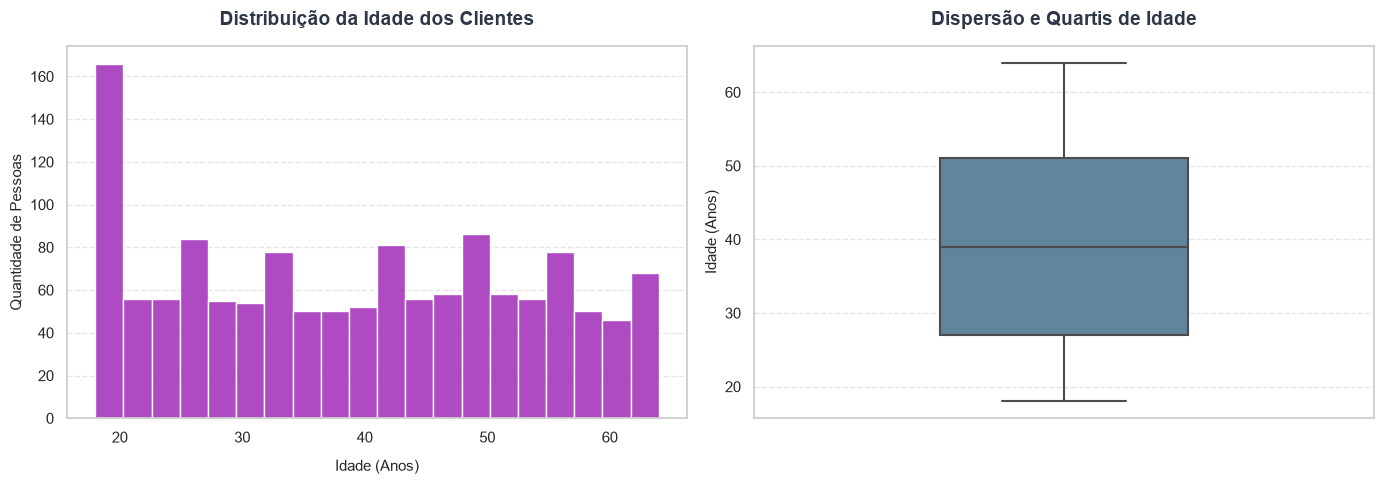

In [70]:
# Criando figura vazia
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

# Configurando o estilo geral
sns.set_theme(style="whitegrid", rc={"axes.grid": False})

# Criando histograma
sns.histplot(df['Idade'], bins=20, ax=axes[0], color="#a02ab8", edgecolor='white', alpha=0.85)
axes[0].set_title('Distribuição da Idade dos Clientes', fontsize=14, pad=15, weight='bold', color='#2d3748')
axes[0].set_xlabel('Idade (Anos)', fontsize=11, labelpad=10)
axes[0].set_ylabel('Quantidade de Pessoas', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

#Criando boxplot
sns.boxplot(data=df, y='Idade', ax=axes[1], color="#5688A6", width=0.4, linewidth=1.5)
axes[1].set_title('Dispersão e Quartis de Idade', fontsize=14, pad=15, weight='bold', color='#2d3748')
axes[1].set_ylabel('Idade (Anos)', fontsize=11)
axes[1].set_xlabel('') # Removendo o texto desnecessário do eixo X
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Ajustando o espaçamento
plt.tight_layout()

# Salvando com alta qualidade na sua pasta automática
plt.savefig('../outputs/graphs/graficos_idade.png', dpi=300, bbox_inches='tight')
plt.show()

In [75]:
# Calculando as medidas descritivas
medidas_idade = df['Idade'].agg(['mean', 'median', 'std', 'min', 'max']).to_frame()
medidas_idade.columns = ['Estatística']
medidas_idade.index = ['Média', 'Mediana', 'Desvio Padrão', 'Mínimo', 'Máximo']
# Formatando e arredondando
medidas_idade.style.format("{:.2f}").set_caption("Medidas Descritivas da Idade")

# Salvando resultados na pasta de tabelas
medidas_idade.to_csv(f'{PASTA_TABELAS}medidas_descritivas_idade.csv', sep=';', encoding='utf-8-sig')